# Testing ondeviceMNIST inference live on webcam-feed


In [3]:
#bitfile_path = 'bitfile_axi_master/system.bit'
#bitfile_path = 'bitfile_axi_stream/system.bit'
#bitfile_path = 'bitfile_FixedHP_axi_master/system.bit'
bitfile_path = 'bitfile_new-model-106000_aximaster/system.bit'

shape_img = (1, 28, 28, 1) # 1 frame, 28 width, 28 height, 1 channel
shape_y = (1, 10) # 1 frame, digits from 0 to 9 

Load the model to the FPGA fabric (PL)

In [4]:
import numpy as np
# import the library/driver which is common for every VItis Unified synthesis
from bitfile_axi_master.axi_master_driver import NeuralNetworkOverlay
#from bitfile_axi_stream.axi_stream_driver import NeuralNetworkOverlay

# create the overlay object
overlay = NeuralNetworkOverlay(bitfile_name=bitfile_path, x_shape=shape_img, y_shape=shape_y, dtype=np.float32)

The jupyter notebook is run as root. To open GUIs we need to configure the environment. In user terminal, run the following to get the display to output to:

```
env | grep DISPLAY
```

Camera we tested with is 30 FPS

Start live inference on the device
It may fail to lock on the camera, but it should be able if rerun

In [11]:
import os
import cv2
os.environ["DISPLAY"] = ":1" # Check terminal `env | grep DISPLAY`
#os.environ["XAUTHORITY"] = "/home/ubuntu/.Xauthority"
os.environ["XAUTHORITY"] = "/run/user/1000/gdm/Xauthority" # Previously ran `xhost +SI:localuser:root`
os.environ["DBUS_SESSION_BUS_ADDRESS"] = "unix:path=/run/user/1000/bus"

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    # Convert full frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Resize full frame to 28x28
    resized = cv2.resize(gray, (28, 28), 
                         #interpolation=cv2.INTER_AREA
                         interpolation=cv2.INTER_LINEAR
                        )

    # Threshold for cleaner digit
    _, resized = cv2.threshold(resized, 100,
                               255, cv2.THRESH_BINARY_INV)
    
    # Smooth edges: Gaussian blur then small morphological closing
    #resized = cv2.GaussianBlur(resized, (3, 3), 0)
    #kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    #resized = cv2.morphologyEx(resized, cv2.MORPH_CLOSE, kernel)
    #resized = cv2.medianBlur(resized, 3)

    # Normalize
    resized = resized.astype("float32") / 255.0

    # Reshape to (1,28,28,1)
    input_img = resized.reshape(1, 28, 28, 1)

    # Do the prediction/run inference
    result = overlay.predict(input_img, debug=False, profile=True)#, encode=np.float32, decode=np.float32)
    digit = np.argmax(result[0])
    confidence = np.max(result[0])

    # Display prediction
    cv2.putText(frame, 
                f"Predicted: {digit} ({confidence:.2f}) in {(result[1]) * 1e3:.3f} ms",
                (50, 50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1, (0,0,255), 2)

    cv2.imshow("Live feed", frame)
    cv2.imshow("MNIST processed feed", resized)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


KeyboardInterrupt: 

....

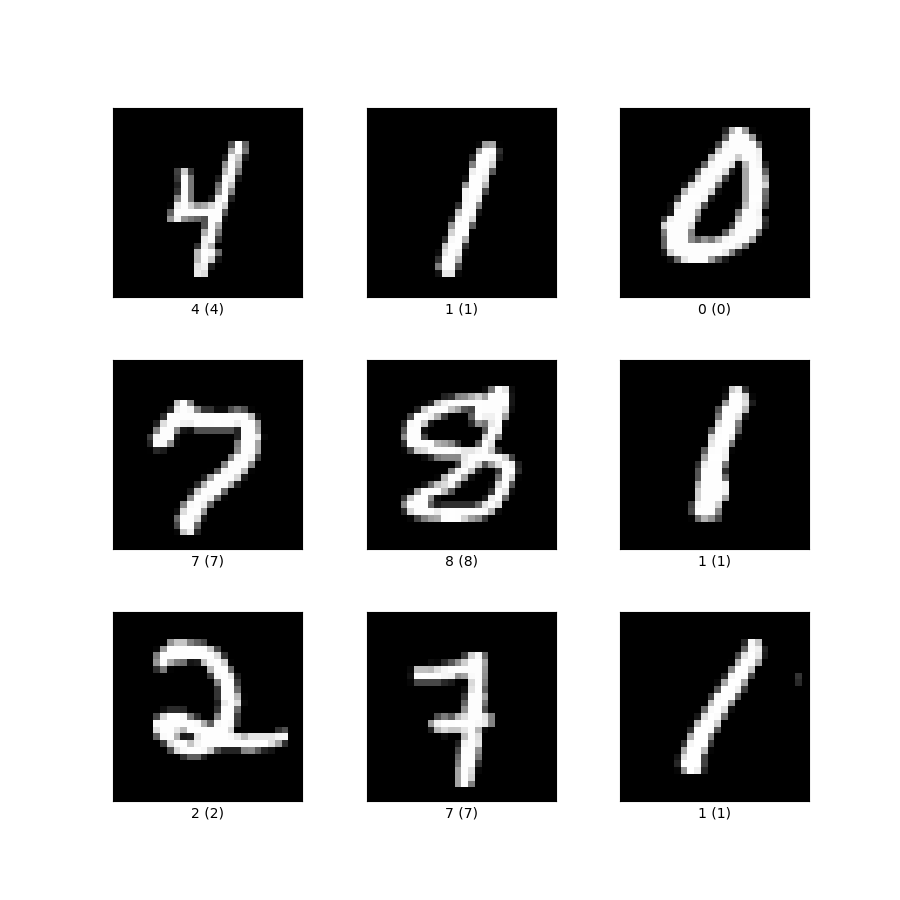

In [12]:
#import pynq
#pynq.PL.reset()

In [13]:
from pynq import Clocks

print(f'CPU:   {Clocks.cpu_mhz:.6f}MHz')
print(f'FCLK0: {Clocks.fclk0_mhz:.6f}MHz')
print(f'FCLK1: {Clocks.fclk1_mhz:.6f}MHz')
print(f'FCLK2: {Clocks.fclk2_mhz:.6f}MHz')
print(f'FCLK3: {Clocks.fclk3_mhz:.6f}MHz')

CPU:   1333.320000MHz
FCLK0: 66.666000MHz
FCLK1: 66.666000MHz
FCLK2: 99.999000MHz
FCLK3: 99.999000MHz
